# Qwen3-VL-4B Fine-tuning — Hotel Room Defect Detection
QLoRA fine-tune via Unsloth. ViT + LLM LoRA (ViT run 2). Run cells top to bottom.

In [18]:
import json
import re
import sys
import random
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from datasets import Dataset
from transformers import EarlyStoppingCallback
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig
from qwen_vl_utils import process_vision_info

ROOT       = Path(".").resolve().parent
CLEAN_DIR  = ROOT / "data" / "clean"
MESSY_DIR  = ROOT / "data" / "messy"
OUTPUT_DIR = ROOT / "outputs" / "lora_adapter_vit"

sys.path.insert(0, str(ROOT))

## Config

In [19]:
MODEL_ID    = "unsloth/Qwen3-VL-4B-Instruct-unsloth-bnb-4bit"

LORA_R      = 32     # restored from 16 — LLM needs full capacity (~66M params); r=16 cost more LLM params than ViT gained
LORA_ALPHA  = 16     # halved from 32 — reduces LoRA scale (alpha/r: 1.0→0.5) to dampen ViT overfitting
LR          = 5e-5   # compromise for single shared LR across LLM+ViT; ViT needs 5-10x lower than LLM optimal (1e-4), ViT ideal ~1e-5, split at 5e-5
EPOCHS      = 10    
BATCH_SIZE  = 2
GRAD_ACCUM  = 4
MAX_SEQ_LEN = 2048
EVAL_SPLIT  = 0.15

MIN_PIXELS  = 256 * 28 * 28
MAX_PIXELS  = 512 * 28 * 28

QUESTION = (
    "Inspect this hotel room for cleanliness defects. "
    "Respond ONLY with valid JSON using this schema: "
    '{"clean": true/false, "defects": [{"object": "...", "type": "...", "description": "..."}]}'
)

## Build Dataset

In [20]:
def make_messy_sample(img_path, defects):
    defect_list = [
        {"object": d["object"], "type": d["label"], "description": d["prompt"]}
        for d in defects
    ]
    answer = json.dumps({"clean": False, "defects": defect_list})
    return {"messages": [
        {"role": "user", "content": [
            {"type": "image", "image": str(img_path)},
            {"type": "text",  "text": QUESTION},
        ]},
        {"role": "assistant", "content": [{"type": "text", "text": answer}]},
    ]}

def make_clean_sample(img_path):
    answer = json.dumps({"clean": True, "defects": []})
    return {"messages": [
        {"role": "user", "content": [
            {"type": "image", "image": str(img_path)},
            {"type": "text",  "text": QUESTION},
        ]},
        {"role": "assistant", "content": [{"type": "text", "text": answer}]},
    ]}

manifest = json.loads((MESSY_DIR / "manifest.json").read_text())
rows = []

for img_name, variants in manifest.items():
    for variant in variants:
        out_path = MESSY_DIR / variant["output"]
        if out_path.exists():
            rows.append(make_messy_sample(out_path, variant["defects"]))

# Repeat each clean image 3x to balance the 1:3 messy:clean ratio
for img_path in sorted(CLEAN_DIR.glob("*.jpg")):
    for _ in range(3):
        rows.append(make_clean_sample(img_path))

random.shuffle(rows)
n_eval   = max(1, int(len(rows) * EVAL_SPLIT))
train_ds = Dataset.from_list(rows[n_eval:])
eval_ds  = Dataset.from_list(rows[:n_eval])

print(f"Train: {len(train_ds)}  Eval: {len(eval_ds)}")

Train: 1112  Eval: 196


## Load Model + LoRA

In [21]:
model, tokenizer = FastVisionModel.from_pretrained(
    MODEL_ID,
    load_in_4bit=True,
    use_gradient_checkpointing="unsloth",
    max_seq_length=MAX_SEQ_LEN,
)

model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers=True,   # key change — LoRA adapters on ViT layers too
    finetune_language_layers=True,
    finetune_attention_modules=True,
    finetune_mlp_modules=True,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=0.10,   # increased from 0.05 — stronger regularization for ViT adapters
    bias="none",
    use_rslora=False,
)

print("Model loaded.")

==((====))==  Unsloth 2026.2.1: Fast Qwen3_Vl patching. Transformers: 4.57.6.
   \\   /|    NVIDIA GeForce RTX 5070 Ti. Num GPUs = 1. Max memory: 15.92 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.1.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.


Model loaded.


## Train

In [22]:
FastVisionModel.for_training(model)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    data_collator=UnslothVisionDataCollator(model, tokenizer),
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    # Stop early if eval_loss doesn't improve for 2 consecutive checks (= 50 steps)
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    args=SFTConfig(
        per_device_train_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM,
        num_train_epochs=EPOCHS,
        learning_rate=LR,
        lr_scheduler_type="cosine",
        warmup_ratio=0.10,   # higher than LLM-only — protects ViT from large early gradients
        weight_decay=0.05,
        max_grad_norm=0.3,
        bf16=torch.cuda.is_bf16_supported(),
        fp16=not torch.cuda.is_bf16_supported(),
        optim="adamw_8bit",
        max_seq_length=MAX_SEQ_LEN,
        eval_strategy="steps",
        eval_steps=25,
        save_steps=25,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        output_dir=str(OUTPUT_DIR / "checkpoints"),
        report_to="none",
        logging_steps=10,
        dataset_text_field="",
        dataset_kwargs={"skip_prepare_dataset": True},
        remove_unused_columns=False,
    ),
)

trainer.train()

Unsloth: Model does not have a default image size - using 512


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,112 | Num Epochs = 10 | Total steps = 1,390
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 78,643,200 of 4,516,459,008 (1.74% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
25,3.024800,2.699176
50,1.770800,1.422645
75,0.667300,0.389475
100,0.213400,0.232142
125,0.137500,0.136883
150,0.088500,0.078139
175,0.069400,0.062640
200,0.044600,0.058447
225,0.057400,0.054163
250,0.054900,0.051482


TrainOutput(global_step=500, training_loss=0.3530167979001999, metrics={'train_runtime': 1415.5087, 'train_samples_per_second': 7.856, 'train_steps_per_second': 0.982, 'total_flos': 2.8877522916827136e+16, 'train_loss': 0.3530167979001999, 'epoch': 3.597122302158273})

## Save Adapter

In [23]:
model.save_pretrained(str(OUTPUT_DIR))
tokenizer.save_pretrained(str(OUTPUT_DIR))
print(f"Adapter saved to {OUTPUT_DIR}")

Adapter saved to C:\Users\ranen\Projects\roomaudit\outputs\lora_adapter_vit


## Results

In [24]:
# Confirm which checkpoint is loaded (trainer.train() restores best via load_best_model_at_end)
best_ckpt = trainer.state.best_model_checkpoint
best_step = int(Path(best_ckpt).name.split("-")[-1]) if best_ckpt else None
print(f"Best checkpoint: step {best_step}, eval_loss {trainer.state.best_metric:.6f}")
print("Running eval on best checkpoint...")
FastVisionModel.for_inference(model)

y_true, y_pred = [], []

def clean_messages(messages):
    # Arrow serialization inserts None for missing keys across content items — strip them
    result = []
    for msg in messages:
        clean_content = [
            {k: v for k, v in item.items() if v is not None}
            for item in msg["content"]
        ]
        result.append({**msg, "content": clean_content})
    return result

for sample in eval_ds:
    gt = json.loads(sample["messages"][1]["content"][0]["text"])
    gt_clean = gt["clean"]

    messages = clean_messages([sample["messages"][0]])
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, _ = process_vision_info(messages)
    inputs = tokenizer(
        text=[text], images=image_inputs, padding=True, return_tensors="pt"
    ).to("cuda")

    out_ids = model.generate(
        **inputs, max_new_tokens=256,
        do_sample=True, temperature=0.1, repetition_penalty=1.05,
    )
    gen_ids     = [o[len(i):] for i, o in zip(inputs.input_ids, out_ids)]
    output_text = tokenizer.batch_decode(gen_ids, skip_special_tokens=True)[0].strip()

    try:
        match = re.search(r"\{.*\}", output_text, re.DOTALL)
        pred       = json.loads(match.group()) if match else {}
        pred_clean = pred.get("clean", True)
    except Exception:
        pred_clean = True

    y_true.append(0 if gt_clean else 1)
    y_pred.append(0 if pred_clean else 1)

print(f"Eval samples: {len(y_true)}")

Best checkpoint: step 450, eval_loss 0.038153
Running eval on best checkpoint...
Eval samples: 196


Accuracy:  0.587
Precision: 0.568
Recall:    0.991
F1:        0.722

Confusion matrix:
  TN=10  FP=80
  FN=1  TP=105


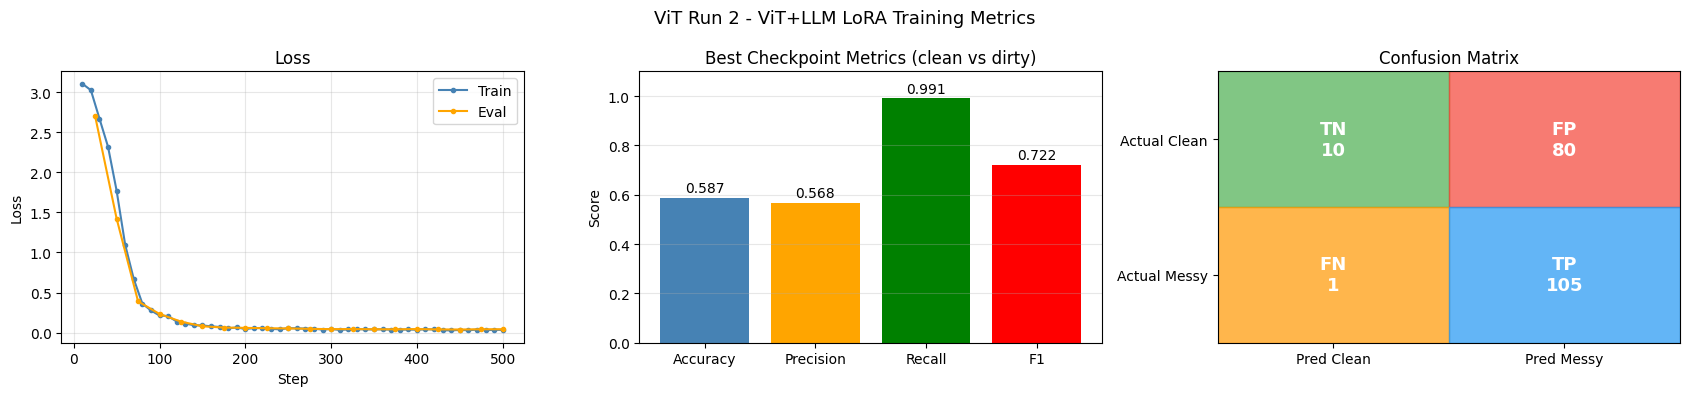

In [27]:
log = trainer.state.log_history
train_steps = [e["step"] for e in log if "loss" in e and "eval_loss" not in e]
train_loss  = [e["loss"] for e in log if "loss" in e and "eval_loss" not in e]
eval_steps  = [e["step"] for e in log if "eval_loss" in e]
eval_loss   = [e["eval_loss"] for e in log if "eval_loss" in e]

tp = sum(1 for t, p in zip(y_true, y_pred) if t == 1 and p == 1)
fp = sum(1 for t, p in zip(y_true, y_pred) if t == 0 and p == 1)
tn = sum(1 for t, p in zip(y_true, y_pred) if t == 0 and p == 0)
fn = sum(1 for t, p in zip(y_true, y_pred) if t == 1 and p == 0)

accuracy  = (tp + tn) / len(y_true) if y_true else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1:        {f1:.3f}")

print(f"\nConfusion matrix:")
print(f"  TN={tn}  FP={fp}")
print(f"  FN={fn}  TP={tp}")

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle("ViT Run 2 - ViT+LLM LoRA Training Metrics", fontsize=13)

axes[0].plot(train_steps, train_loss, label="Train", color="steelblue", marker="o", markersize=3)
axes[0].plot(eval_steps,  eval_loss,  label="Eval",  color="orange",   marker="o", markersize=3)
axes[0].set_title("Loss")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

labels = ["Accuracy", "Precision", "Recall", "F1"]
values = [accuracy, precision, recall, f1]
colors = ["steelblue", "orange", "green", "red"]
bars   = axes[1].bar(labels, values, color=colors)
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=10)
axes[1].set_ylim(0, 1.1)
axes[1].set_title("Best Checkpoint Metrics (clean vs dirty)")
axes[1].set_ylabel("Score")
axes[1].grid(True, alpha=0.3, axis="y")

# Confusion matrix: rows = actual, cols = predicted
cm = [[tn, fp], [fn, tp]]
cm_labels = [["TN", "FP"], ["FN", "TP"]]
cm_colors = [["#4CAF50", "#F44336"], ["#FF9800", "#2196F3"]]
ax = axes[2]
for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle((j, 1 - i), 1, 1, color=cm_colors[i][j], alpha=0.7))
        ax.text(j + 0.5, 1.5 - i, f"{cm_labels[i][j]}\n{cm[i][j]}",
                ha="center", va="center", fontsize=13, fontweight="bold", color="white")
ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_xticklabels(["Pred Clean", "Pred Messy"])
ax.set_yticks([0.5, 1.5])
ax.set_yticklabels(["Actual Messy", "Actual Clean"])
ax.set_title("Confusion Matrix")

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "metrics.png"), dpi=150)
plt.show()


In [28]:
# Compare best vs final checkpoint of this run — uses trainer.state.global_step to avoid stale checkpoints on disk
final_step = trainer.state.global_step
final_ckpt = str(OUTPUT_DIR / "checkpoints" / f"checkpoint-{final_step}")
final_ckpt = final_ckpt if Path(final_ckpt).exists() else None

if final_ckpt and final_ckpt != trainer.state.best_model_checkpoint:
    print(f"Loading final checkpoint (step {final_step}) for comparison...")
    model.load_adapter(final_ckpt, adapter_name="default")
    FastVisionModel.for_inference(model)

    y_true_f, y_pred_f = [], []
    for sample in eval_ds:
        gt = json.loads(sample["messages"][1]["content"][0]["text"])
        gt_clean = gt["clean"]

        messages = clean_messages([sample["messages"][0]])
        text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        image_inputs, _ = process_vision_info(messages)
        inputs = tokenizer(
            text=[text], images=image_inputs, padding=True, return_tensors="pt"
        ).to("cuda")

        out_ids = model.generate(
            **inputs, max_new_tokens=256,
            do_sample=True, temperature=0.1, repetition_penalty=1.05,
        )
        gen_ids     = [o[len(i):] for i, o in zip(inputs.input_ids, out_ids)]
        output_text = tokenizer.batch_decode(gen_ids, skip_special_tokens=True)[0].strip()

        try:
            match = re.search(r"\{.*\}", output_text, re.DOTALL)
            pred       = json.loads(match.group()) if match else {}
            pred_clean = pred.get("clean", True)
        except Exception:
            pred_clean = True

        y_true_f.append(0 if gt_clean else 1)
        y_pred_f.append(0 if pred_clean else 1)

    def _metrics(yt, yp):
        tp = sum(1 for t, p in zip(yt, yp) if t == 1 and p == 1)
        fp = sum(1 for t, p in zip(yt, yp) if t == 0 and p == 1)
        tn = sum(1 for t, p in zip(yt, yp) if t == 0 and p == 0)
        fn = sum(1 for t, p in zip(yt, yp) if t == 1 and p == 0)
        acc  = (tp + tn) / len(yt)
        prec = tp / (tp + fp) if (tp + fp) else 0
        rec  = tp / (tp + fn) if (tp + fn) else 0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0
        return acc, prec, rec, f1

    ba, bp, br, bf   = _metrics(y_true, y_pred)
    fa, fp2, fr, ff  = _metrics(y_true_f, y_pred_f)
    print(f"\n{'':12} {'Best (step '+str(best_step)+')':>22} {'Final (step '+str(final_step)+')':>22}")
    for name, bv, fv in [("Accuracy", ba, fa), ("Precision", bp, fp2), ("Recall", br, fr), ("F1", bf, ff)]:
        print(f"{name:12} {bv:>22.3f} {fv:>22.3f}")
else:
    print("Final checkpoint is the best checkpoint — no comparison needed.")

Loading final checkpoint (step 500) for comparison...

                    Best (step 450)       Final (step 500)
Accuracy                      0.587                  0.546
Precision                     0.568                  0.544
Recall                        0.991                  1.000
F1                            0.722                  0.704
